# Migrating Ice Wall: a minimal full-Stokes test

This notebook tests whether flow beneath a slowly migrating Ice Wall can turn initially monotonic age layers into the observed vertical order: old ice, Pleistocene ice, then older ice from top to bottom. Lateral juxtaposition and large layer relief are not success.

The velocity is an actual two-dimensional full-Stokes finite-element solution. Firedrake uses continuous quadratic velocity and continuous linear pressure (P2--P1), the complete symmetric velocity gradient, incompressibility, and gravity. No interior velocity is prescribed and no shallow or depth-integrated approximation is used.

In [1]:
import warnings
warnings.filterwarnings("ignore", message="Unable to import recommended hash.*")
warnings.filterwarnings("ignore", message="IProgress not found.*")

from importlib.metadata import version
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from matplotlib.colors import TwoSlopeNorm
import icepack
from firedrake import (
    UnitSquareMesh, VectorFunctionSpace, FunctionSpace, Function, Constant,
    SpatialCoordinate, TrialFunctions, TestFunctions, DirichletBC,
    as_vector, inner, sym, grad, div, dot, dx, ds, FacetNormal, assemble,
    project, solve,
)

print(f"Firedrake {version('firedrake')} | Icepack {version('icepack')}")

Firedrake 0.14.dev0 | Icepack 1.1.0


## Geometry, equations, and boundary conditions

The flow band is 8 km long with a flat bed. Its arctangent surface rises by approximately 190 m across a 0.4 km half-width, representing the steep Ice Wall as a smoothed step. Ice has constant density 917 kg/m3 and constant Newtonian viscosity 5e10 Pa yr. The viscosity is an idealized cold-ice effective viscosity, not a fitted Allan Hills value.

For velocity **u**, pressure p, test velocity **v**, and pressure test q, the weak problem is

Integral_V [2 mu D(u):D(v) - p div(v) - q div(u)] dV = Integral_V rho g dot v dV.

where D(u) is the full symmetric gradient. The bed is no slip. The two side boundaries have mass-balanced, depth-varying throughflow profiles and zero vertical velocity. The upper surface has no velocity condition; omission of a boundary traction term imposes zero traction there. Thus the surface is stress free. Its instantaneous normal velocity implies the accumulation or ablation needed to maintain the prescribed shape.

In [2]:
L = 8_000.0                 # m
mean_height = 400.0         # m
height_jump = 200.0         # m
wall_half_width = 400.0     # m
rho = 917.0                 # kg/m3
gravity = 9.81              # m/s2
viscosity = 5.0e10          # Pa yr
left_mean_speed = 0.02      # m/yr
wall_speed = 0.01           # m/yr, toward +x
migration_time = 100_000.0  # yr
particle_dt = 500.0         # yr

def surface(x):
    return mean_height + height_jump / np.pi * np.arctan(np.asarray(x) / wall_half_width)

def solve_full_stokes(nx, nz):
    mesh = UnitSquareMesh(nx, nz, quadrilateral=False)
    coordinates = mesh.coordinates.dat.data
    xi = coordinates[:, 0].copy()
    eta = coordinates[:, 1].copy()
    x_nodes = -0.5 * L + L * xi
    coordinates[:, 0] = x_nodes
    coordinates[:, 1] = eta * surface(x_nodes)

    V = VectorFunctionSpace(mesh, "CG", 2)
    Q = FunctionSpace(mesh, "CG", 1)
    Z = V * Q
    z = SpatialCoordinate(mesh)[1]
    left_height = float(surface(-0.5 * L))
    right_height = float(surface(0.5 * L))
    right_mean_speed = left_mean_speed * left_height / right_height

    left_velocity = Function(V).interpolate(as_vector((
        1.5 * left_mean_speed * (2 * z / left_height - (z / left_height) ** 2), 0.0
    )))
    right_velocity = Function(V).interpolate(as_vector((
        1.5 * right_mean_speed * (2 * z / right_height - (z / right_height) ** 2), 0.0
    )))
    bcs = [
        DirichletBC(Z.sub(0), Constant((0.0, 0.0)), 3),
        DirichletBC(Z.sub(0), left_velocity, 1),
        DirichletBC(Z.sub(0), right_velocity, 2),
    ]

    u, p = TrialFunctions(Z)
    v, q = TestFunctions(Z)
    bilinear = (
        2 * Constant(viscosity) * inner(sym(grad(u)), sym(grad(v)))
        - p * div(v) - q * div(u)
    ) * dx
    forcing = dot(Constant((0.0, -rho * gravity)), v) * dx
    solution = Function(Z, name=f"full_stokes_{nx}_{nz}")
    solve(
        bilinear == forcing, solution, bcs=bcs,
        solver_parameters={
            "ksp_type": "preonly", "pc_type": "lu",
            "pc_factor_mat_solver_type": "mumps",
        },
    )
    velocity, pressure = solution.subfunctions
    velocity.rename("full-Stokes velocity")
    pressure.rename("pressure")

    P1 = FunctionSpace(mesh, "CG", 1)
    horizontal = Function(P1).interpolate(velocity[0])
    vertical = Function(P1).interpolate(velocity[1])
    shear = project(velocity[0].dx(1), P1)
    wall_zone = np.abs(mesh.coordinates.dat.data_ro[:, 0]) <= 1_500.0
    area = float(assemble(Constant(1.0) * dx(domain=mesh)))
    rms_divergence = np.sqrt(float(assemble(div(velocity) ** 2 * dx)) / area)
    integrated_divergence = float(assemble(div(velocity) * dx))

    normal = FacetNormal(mesh)
    wall_frame_velocity = as_vector((velocity[0] - wall_speed, velocity[1]))
    boundary_fluxes = {
        name: float(assemble(dot(wall_frame_velocity, normal) * ds(marker)))
        for name, marker in (("left", 1), ("right", 2), ("bed", 3), ("surface", 4))
    }
    flux_scale = sum(abs(value) for value in boundary_fluxes.values())
    mass_residual = sum(boundary_fluxes.values())

    return {
        "mesh": mesh, "velocity": velocity, "pressure": pressure,
        "horizontal": horizontal, "vertical": vertical, "shear": shear,
        "rms_divergence": rms_divergence,
        "integrated_divergence": integrated_divergence,
        "boundary_fluxes": boundary_fluxes, "mass_residual": mass_residual,
        "relative_mass_residual": abs(mass_residual) / max(flux_scale, 1e-30),
        "max_u": float(np.max(np.abs(horizontal.dat.data_ro))),
        "max_w": float(np.max(np.abs(vertical.dat.data_ro))),
        "max_shear": float(np.max(np.abs(shear.dat.data_ro))),
        "max_wall_shear": float(np.max(np.abs(shear.dat.data_ro[wall_zone]))),
    }


In [3]:
coarse = solve_full_stokes(32, 8)
fine = solve_full_stokes(64, 16)

for label, result in (("32 x 8", coarse), ("64 x 16", fine)):
    print(
        f"{label}: max |u| = {result['max_u']:.4f} m/yr, "
        f"max |w| = {result['max_w']:.4f} m/yr, "
        f"max |du/dz| = {result['max_shear']:.3e} 1/yr, "
        f"wall-zone max = {result['max_wall_shear']:.3e} 1/yr"
    )
    print(
        f"  RMS(div u) = {result['rms_divergence']:.3e} 1/yr, "
        f"integral(div u) = {result['integrated_divergence']:.3e} m2/yr, "
        f"relative boundary-flux residual = {result['relative_mass_residual']:.3e}"
    )
print(
    f"Factor-two change in domain / wall-zone max shear: "
    f"{abs(fine['max_shear'] - coarse['max_shear']) / fine['max_shear']:.1%} / "
    f"{abs(fine['max_wall_shear'] - coarse['max_wall_shear']) / fine['max_wall_shear']:.1%}"
)
print("Fine wall-frame boundary fluxes (m2/yr):", fine["boundary_fluxes"])

32 x 8: max |u| = 0.0300 m/yr, max |w| = 0.0094 m/yr, max |du/dz| = 2.008e-04 1/yr, wall-zone max = 6.586e-06 1/yr
  RMS(div u) = 2.507e-06 1/yr, integral(div u) = 1.429e-15 m2/yr, relative boundary-flux residual = 1.232e-15
64 x 16: max |u| = 0.0300 m/yr, max |w| = 0.0105 m/yr, max |du/dz| = 1.983e-04 1/yr, wall-zone max = 6.619e-06 1/yr
  RMS(div u) = 1.411e-06 1/yr, integral(div u) = 1.357e-15 m2/yr, relative boundary-flux residual = 1.993e-15
Factor-two change in domain / wall-zone max shear: 1.2% / 0.5%
Fine wall-frame boundary fluxes (m2/yr): {'left': -3.063451034861105, 'right': 1.1903531045833204, 'bed': 0.0, 'surface': 1.8730979302777966}


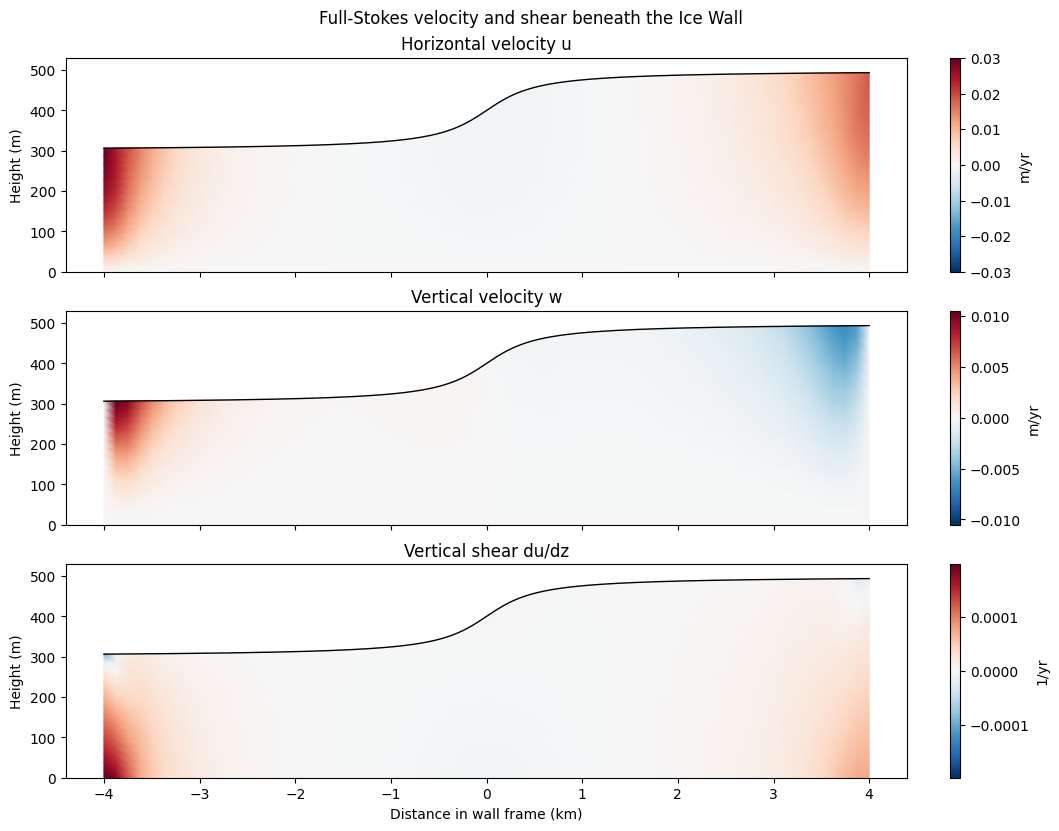

In [4]:
mesh = fine["mesh"]
coordinates = mesh.coordinates.dat.data_ro
triangles = np.asarray(mesh.coordinates.cell_node_map().values, dtype=int)
triangulation = mtri.Triangulation(coordinates[:, 0] / 1000, coordinates[:, 1], triangles)
x_surface = np.linspace(-0.5 * L, 0.5 * L, 800)

fields = [
    (fine["horizontal"].dat.data_ro, "Horizontal velocity u", "m/yr"),
    (fine["vertical"].dat.data_ro, "Vertical velocity w", "m/yr"),
    (fine["shear"].dat.data_ro, "Vertical shear du/dz", "1/yr"),
]
fig, axes = plt.subplots(3, 1, figsize=(10.5, 8.2), sharex=True, constrained_layout=True)
for axis, (data, title, units) in zip(axes, fields):
    limit = float(np.max(np.abs(data)))
    norm = TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit)
    image = axis.tripcolor(triangulation, data, shading="gouraud", cmap="RdBu_r", norm=norm)
    axis.plot(x_surface / 1000, surface(x_surface), color="black", lw=1)
    axis.set_ylabel("Height (m)")
    axis.set_title(title)
    axis.set_ylim(0, 530)
    fig.colorbar(image, ax=axis, label=units)
axes[-1].set_xlabel("Distance in wall frame (km)")
fig.suptitle("Full-Stokes velocity and shear beneath the Ice Wall")
plt.show()

## Wall-frame material layers and vertical cores

The Stokes solution is instantaneous. Slow translation is represented in the wall frame by advecting particles with (u - c_wall, w), where c_wall = 0.01 m/yr. Over 100 kyr the wall migrates 1 km relative to the bed. Nine initially monotonic, terrain-following layers carry fixed ages from 0.2 Ma near the surface to 5.2 Ma near the bed. Midpoint integration moves the markers without interpolating age between layers. Markers that leave the prescribed domain are removed.

Vertical cores are scanned every 25 m. The best core is selected lexicographically by the number of bracketed Pleistocene minima, the number of downward age reversals, and the number of layer intersections; distance from the wall center breaks ties. This rule favors the observed structure without selecting a column by eye.

In [5]:
layer_ages = np.array([0.2, 0.5, 0.8, 1.2, 2.0, 3.0, 4.0, 5.0, 5.2])
layer_eta = np.linspace(0.85, 0.15, len(layer_ages))
initial_x = np.linspace(-2_800.0, 2_200.0, 81)
initial_lines = [np.column_stack((initial_x, eta * surface(initial_x))) for eta in layer_eta]
points = np.vstack(initial_lines)
alive = np.ones(len(points), dtype=bool)

def inside_domain(query):
    return (
        (query[:, 0] > -0.5 * L + 1e-5) & (query[:, 0] < 0.5 * L - 1e-5)
        & (query[:, 1] > 1e-5) & (query[:, 1] < surface(query[:, 0]) - 1e-5)
    )

def wall_frame_velocity(query):
    values = np.asarray(fine["velocity"].at(query, tolerance=1e-7), dtype=float)
    values[:, 0] -= wall_speed
    return values

for _ in range(round(migration_time / particle_dt)):
    indices = np.where(alive)[0]
    start = points[indices]
    k1 = wall_frame_velocity(start)
    midpoint = start + 0.5 * particle_dt * k1
    midpoint_ok = inside_domain(midpoint)
    alive[indices[~midpoint_ok]] = False
    indices = indices[midpoint_ok]
    start = start[midpoint_ok]
    midpoint = midpoint[midpoint_ok]
    if len(indices) == 0:
        break
    k2 = wall_frame_velocity(midpoint)
    candidate = start + particle_dt * k2
    candidate_ok = inside_domain(candidate)
    alive[indices[~candidate_ok]] = False
    points[indices[candidate_ok]] = candidate[candidate_ok]

final_lines = np.split(points, len(layer_ages))
line_alive = np.split(alive, len(layer_ages))
overturned_by_layer = [
    int(np.count_nonzero((np.diff(line[:, 0]) < 0) & valid[:-1] & valid[1:]))
    for line, valid in zip(final_lines, line_alive)
]
overturned_segments = int(sum(overturned_by_layer))
folded_layers = int(sum(count > 0 for count in overturned_by_layer))

def vertical_intersections(line, valid, x_core):
    heights = []
    for first, second, first_ok, second_ok in zip(line[:-1], line[1:], valid[:-1], valid[1:]):
        crosses = (first[0] - x_core) * (second[0] - x_core) <= 0 and second[0] != first[0]
        if first_ok and second_ok and crosses:
            fraction = (x_core - first[0]) / (second[0] - first[0])
            heights.append(first[1] + fraction * (second[1] - first[1]))
    return heights

def core_at(x_core):
    records = []
    for age, line, valid in zip(layer_ages, final_lines, line_alive):
        records.extend((height, age) for height in vertical_intersections(line, valid, x_core))
    records.sort(reverse=True)
    ages = np.array([age for _, age in records])
    reversals = int(np.count_nonzero(np.diff(ages) < 0)) if len(ages) > 1 else 0
    minima = int(sum(
        ages[i] <= 1.0 and ages[i] < ages[i - 1] and ages[i] < ages[i + 1]
        for i in range(1, len(ages) - 1)
    ))
    return records, reversals, minima

best = None
for x_core in np.linspace(-3_000.0, 3_000.0, 241):
    records, reversals, minima = core_at(x_core)
    score = (minima, reversals, len(records), -abs(x_core))
    if best is None or score > best[0]:
        best = (score, x_core, records, reversals, minima)

_, best_x, best_records, best_reversals, best_minima = best
best_heights = np.array([height for height, _ in best_records])
best_ages = np.array([age for _, age in best_records])
age_sequence = " -> ".join(f"{age:.1f}" for age in best_ages)
print(f"Wall migration distance: {wall_speed * migration_time / 1000:.2f} km")
print(f"Surviving markers: {alive.sum()} / {len(alive)}")
print(f"Folded layers: {folded_layers} / {len(layer_ages)}; overturned segments: {overturned_segments}")
print(f"Best core x: {best_x / 1000:.3f} km")
print(f"Top-to-bottom ages (Ma): {age_sequence}")
print(f"Layer-order reversals: {best_reversals} (observed target: 1)")
print(f"Bracketed Pleistocene minima: {best_minima} (observed target: 1)")

Wall migration distance: 1.00 km
Surviving markers: 667 / 729
Folded layers: 0 / 9; overturned segments: 0
Best core x: 0.000 km
Top-to-bottom ages (Ma): 0.2 -> 0.5 -> 0.8 -> 1.2 -> 2.0 -> 3.0 -> 4.0 -> 5.0 -> 5.2
Layer-order reversals: 0 (observed target: 1)
Bracketed Pleistocene minima: 0 (observed target: 1)


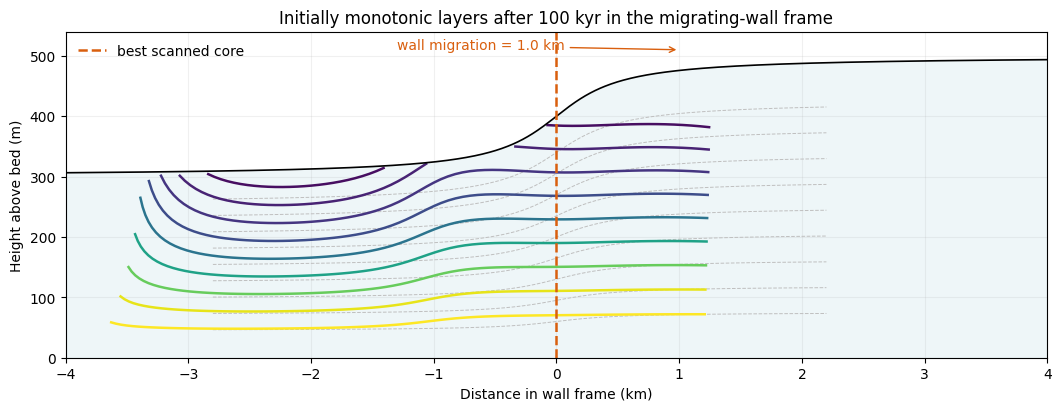

In [6]:
fig, ax = plt.subplots(figsize=(10.5, 4.0), constrained_layout=True)
ax.fill_between(x_surface / 1000, 0, surface(x_surface), color="#eef6f8")
for age, initial, final, valid in zip(layer_ages, initial_lines, final_lines, line_alive):
    ax.plot(initial[:, 0] / 1000, initial[:, 1], color="0.75", ls="--", lw=0.7)
    visible = final.copy()
    visible[~valid] = np.nan
    ax.plot(visible[:, 0] / 1000, visible[:, 1], color=plt.cm.viridis(age / layer_ages.max()), lw=1.8)
ax.plot(x_surface / 1000, surface(x_surface), color="black", lw=1.2)
ax.axvline(best_x / 1000, color="#d95f0e", ls="--", lw=1.8, label="best scanned core")
ax.annotate(
    f"wall migration = {wall_speed * migration_time / 1000:.1f} km",
    xy=(1.0, 510), xytext=(-1.3, 510),
    arrowprops={"arrowstyle": "->", "color": "#d95f0e"}, color="#d95f0e",
)
ax.set(xlabel="Distance in wall frame (km)", ylabel="Height above bed (m)",
       title="Initially monotonic layers after 100 kyr in the migrating-wall frame",
       xlim=(-4, 4), ylim=(0, 540))
ax.legend(frameon=False)
ax.grid(alpha=0.18)
plt.show()

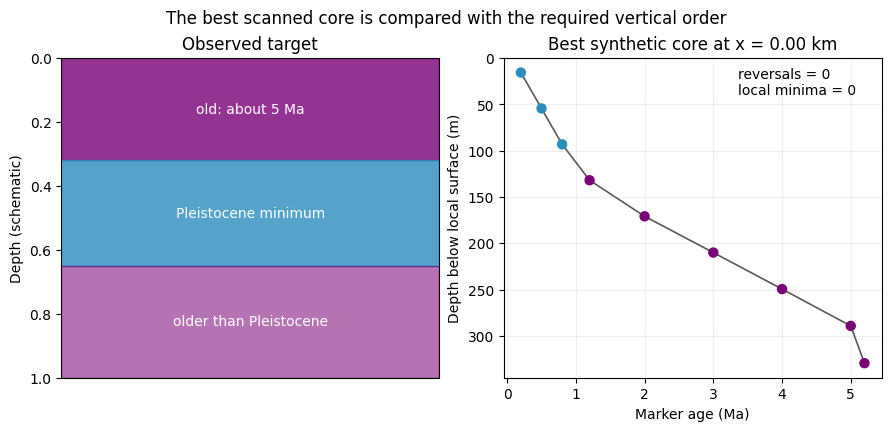

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(8.8, 4.2), constrained_layout=True)
axes[0].axhspan(0, 0.32, color="#7a0177", alpha=0.8)
axes[0].axhspan(0.32, 0.65, color="#2b8cbe", alpha=0.8)
axes[0].axhspan(0.65, 1, color="#7a0177", alpha=0.55)
axes[0].text(0.5, 0.16, "old: about 5 Ma", color="white", ha="center", va="center")
axes[0].text(0.5, 0.485, "Pleistocene minimum", color="white", ha="center", va="center")
axes[0].text(0.5, 0.825, "older than Pleistocene", color="white", ha="center", va="center")
axes[0].set(xlim=(0, 1), ylim=(1, 0), xticks=[], ylabel="Depth (schematic)", title="Observed target")

best_depths = surface(best_x) - best_heights
point_colors = ["#2b8cbe" if age <= 1.0 else "#7a0177" for age in best_ages]
axes[1].plot(best_ages, best_depths, color="0.35", lw=1.2)
axes[1].scatter(best_ages, best_depths, c=point_colors, s=42, zorder=3)
axes[1].set(xlabel="Marker age (Ma)", ylabel="Depth below local surface (m)",
            title=f"Best synthetic core at x = {best_x / 1000:.2f} km")
axes[1].invert_yaxis()
axes[1].grid(alpha=0.2)
axes[1].text(0.62, 0.97, f"reversals = {best_reversals}\nlocal minima = {best_minima}",
             transform=axes[1].transAxes, va="top")
fig.suptitle("The best scanned core is compared with the required vertical order")
plt.show()

## Interpretation and limits

The 100 kyr experiment produces no folded layer, no overturned segment, no downward age reversal, and no bracketed Pleistocene minimum. Even the objectively best core retains ages 0.2, 0.5, 0.8, 1.2, 2.0, 3.0, 4.0, 5.0, and 5.2 Ma from top to bottom. The model therefore fails the observed vertical old--Pleistocene--older order.

In the framework of [Waddington, Bolzan, and Alley (2001)](https://doi.org/10.3189/172756501781831756), the Ice Wall can supply a seed wrinkle. Subsequent simple shear must rotate part of that wrinkle through vertical to overturn it; pure shear tends to flatten it. This solve reaches a domain maximum |du/dz| near 2e-4 /yr, but the largest values occur at the imposed side profiles. More importantly, the finite material lines remain single valued. The rate alone therefore does not establish overturning.

The factor-two mesh test changes maximum shear by only a few percent, and the net wall-frame boundary flux closes to machine precision. Pointwise divergence is not identically zero because incompressibility is enforced weakly, but its RMS decreases on the finer mesh. This calculation is not a reconstruction: it assumes linear viscosity, steady two-dimensional flow, idealized side throughflow, a fixed stress-free surface translated at constant speed, and no evolving accumulation, thermodynamics, or bed topography. Markers that cross the prescribed boundary are removed. The negative result rejects this parameterized smooth-wall history, not every migrating-wall mechanism.